In [119]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

#HW09
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, random_split
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

Device: cuda
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [120]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
RANDOM_STATE = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [121]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [122]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split = "balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split = "balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print(len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
47
train size: 112800
test size: 18800


In [123]:

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


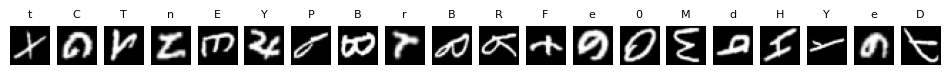

In [124]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=20)

In [125]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 47])


In [126]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [127]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [128]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 7,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history


epoch 01/7 | train loss=1.4948, acc=0.5831 | val loss=1.0135, acc=0.7025
epoch 02/7 | train loss=0.8512, acc=0.7425 | val loss=0.7554, acc=0.7719
epoch 03/7 | train loss=0.6775, acc=0.7863 | val loss=0.6764, acc=0.7896
epoch 04/7 | train loss=0.5906, acc=0.8092 | val loss=0.6067, acc=0.8070
epoch 05/7 | train loss=0.5353, acc=0.8244 | val loss=0.5866, acc=0.8109
epoch 06/7 | train loss=0.4962, acc=0.8333 | val loss=0.5471, acc=0.8238
epoch 07/7 | train loss=0.4690, acc=0.8405 | val loss=0.5395, acc=0.8262


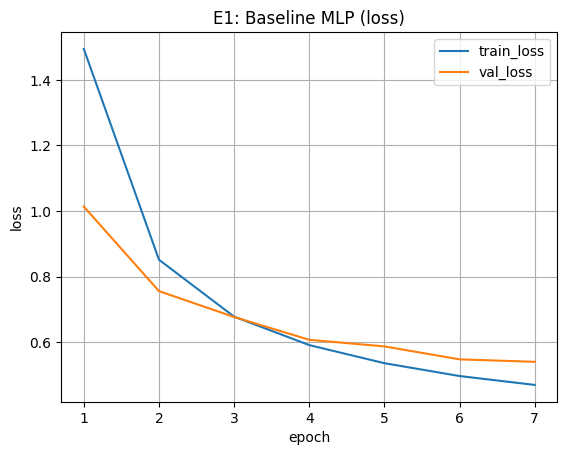

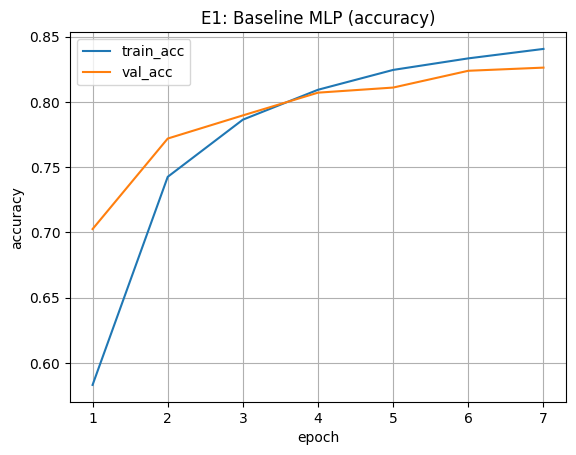

In [129]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    early_stopping=None
)

plot_history(history_baseline, title="E1: Baseline MLP")

epoch 01/7 | train loss=1.8301, acc=0.4814 | val loss=1.0225, acc=0.6983
epoch 02/7 | train loss=1.1430, acc=0.6560 | val loss=0.8115, acc=0.7522
epoch 03/7 | train loss=0.9923, acc=0.6967 | val loss=0.7198, acc=0.7710
epoch 04/7 | train loss=0.9043, acc=0.7180 | val loss=0.6650, acc=0.7907
epoch 05/7 | train loss=0.8545, acc=0.7318 | val loss=0.6307, acc=0.7993
epoch 06/7 | train loss=0.8174, acc=0.7433 | val loss=0.6157, acc=0.8034
epoch 07/7 | train loss=0.7921, acc=0.7479 | val loss=0.5881, acc=0.8105


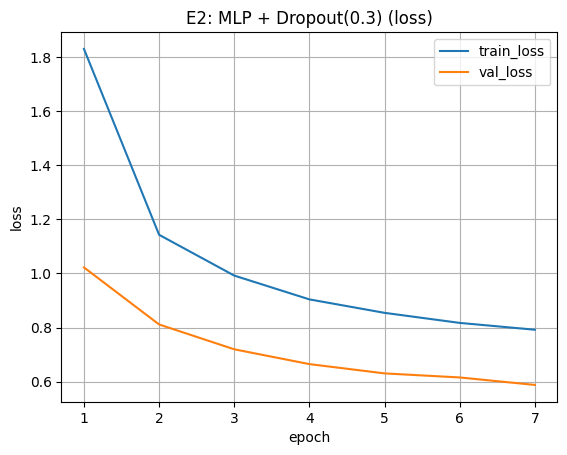

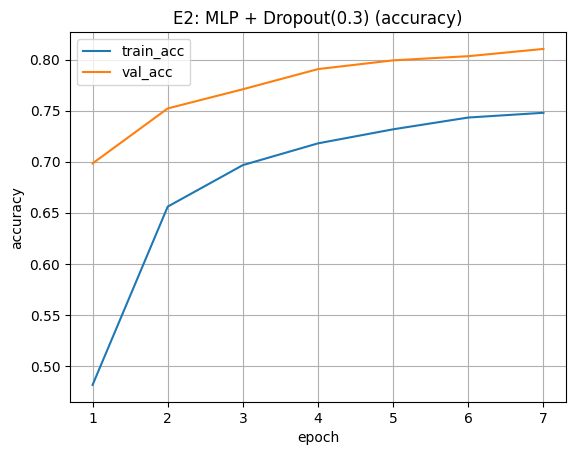

In [130]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    early_stopping=None
)

plot_history(history_dropout, title="E2: MLP + Dropout(0.3)")

epoch 01/7 | train loss=1.1455, acc=0.7092 | val loss=0.6696, acc=0.7941
epoch 02/7 | train loss=0.5498, acc=0.8228 | val loss=0.5482, acc=0.8214
epoch 03/7 | train loss=0.4534, acc=0.8473 | val loss=0.5061, acc=0.8339
epoch 04/7 | train loss=0.4012, acc=0.8623 | val loss=0.4826, acc=0.8400
epoch 05/7 | train loss=0.3669, acc=0.8713 | val loss=0.4882, acc=0.8349
epoch 06/7 | train loss=0.3370, acc=0.8794 | val loss=0.4751, acc=0.8401
epoch 07/7 | train loss=0.3166, acc=0.8854 | val loss=0.4727, acc=0.8468


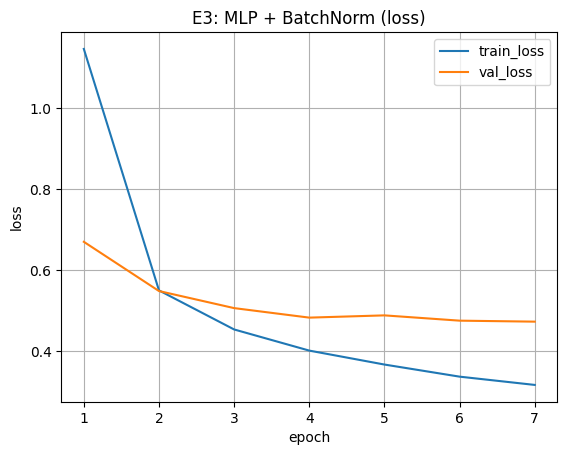

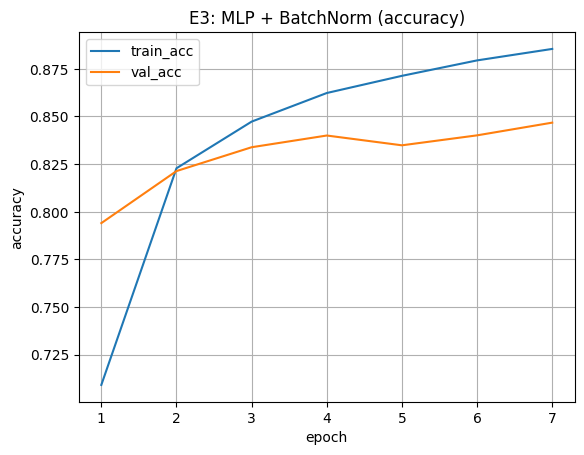

In [131]:
set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    early_stopping=None
)

plot_history(history_bn, title="E3: MLP + BatchNorm")

epoch 01/50 | train loss=1.1455, acc=0.7092 | val loss=0.6696, acc=0.7941
epoch 02/50 | train loss=0.5498, acc=0.8228 | val loss=0.5482, acc=0.8214
epoch 03/50 | train loss=0.4534, acc=0.8473 | val loss=0.5061, acc=0.8339
epoch 04/50 | train loss=0.4012, acc=0.8623 | val loss=0.4826, acc=0.8400
epoch 05/50 | train loss=0.3669, acc=0.8713 | val loss=0.4882, acc=0.8349
epoch 06/50 | train loss=0.3370, acc=0.8794 | val loss=0.4751, acc=0.8401
epoch 07/50 | train loss=0.3166, acc=0.8854 | val loss=0.4727, acc=0.8468
epoch 08/50 | train loss=0.2959, acc=0.8913 | val loss=0.4767, acc=0.8428
epoch 09/50 | train loss=0.2802, acc=0.8959 | val loss=0.4795, acc=0.8450
epoch 10/50 | train loss=0.2637, acc=0.9011 | val loss=0.4886, acc=0.8428
epoch 11/50 | train loss=0.2528, acc=0.9038 | val loss=0.4865, acc=0.8459
EarlyStopping: остановка на эпохе 11. Лучший val_acc=0.8468


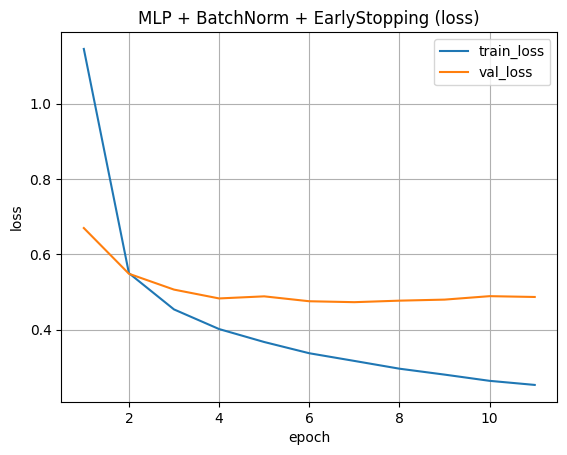

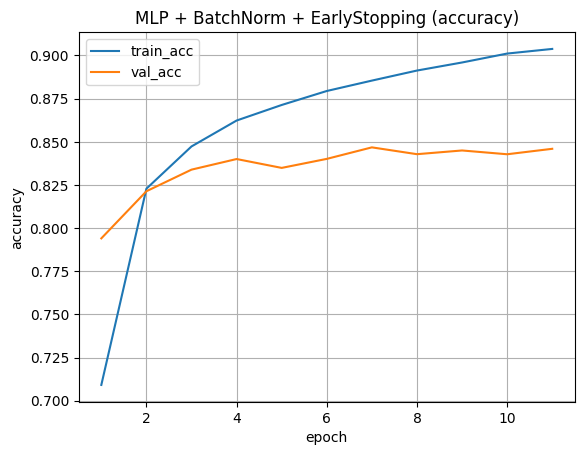

E4: batchnorm + earlystopping test: loss=0.4872, acc=0.8407
saved to artifacts/best_model.pt size: 971765 bytes


In [133]:

set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"E4: batchnorm + earlystopping test: loss={test_loss:.4f}, acc={test_acc:.4f}")

tmp_path = 'artifacts/best_model.pt'
torch.save(combo_model.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')

In [134]:
@dataclass
class DataConfig:
    dataset_name: str = "EMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.15
    num_workers: int = 0
    fast_mode: bool = True
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

def _try_load_torchvision_dataset(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms

    name = cfg.dataset_name.upper().strip()

    if name in {"KMNIST", "EMNIST"}:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    if name == "KMNIST":
        train_ds = datasets.KMNIST(root=cfg.data_dir, train=True, download=True, transform=transform)
        test_ds  = datasets.KMNIST(root=cfg.data_dir, train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 10, "torchvision.KMNIST (28x28, 10 классов)"

    if name == "EMNIST":
        train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
        test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"

    if name == "CIFAR10":
        transform_cifar = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
        ])
        train_ds = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=transform_cifar)
        test_ds  = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=transform_cifar)
        return train_ds, test_ds, 32 * 32 * 3, 10, "torchvision.CIFAR10 (32x32x3, 10 классов)"

    raise ValueError(f"Unknown torchvision dataset_name={cfg.dataset_name!r}")

def _load_digits_fallback(cfg: DataConfig):
    """Запасной вариант без torchvision: sklearn.datasets.load_digits."""
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split

    digits = load_digits()
    X = digits.data.astype(np.float32)     # (n, 64)
    y = digits.target.astype(np.int64)     # (n,)

    # Нормируем в [0, 1]
    X = X / (X.max() + 1e-8)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
    return train_ds, test_ds, X.shape[1], int(y.max() + 1), "sklearn.load_digits (8x8 => 64 признака, 10 классов) [fallback]"

def load_data(cfg: DataConfig):
    try:
        train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset(cfg)
    except Exception as e:
        print("torchvision недоступен или датасет не загрузился. Используем fallback digits. Причина:", repr(e))
        cfg.dataset_name = "DIGITS_FALLBACK"
        train_ds, test_ds, input_dim, num_classes, info = _load_digits_fallback(cfg)

    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds
        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)

Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47


In [135]:
def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x

print("x_flat:", x_flat.shape)

x: <class 'torch.Tensor'> torch.Size([128, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([128]) torch.int64
x_flat: torch.Size([128, 784])


In [136]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 256, hidden2: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(model)
print("Trainable params:", count_params(model))

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable params: 239919


In [137]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=6, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

    return history


def plot_history(hist, title=""):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

Epoch 01/7 | train loss 2.4868, acc 0.353 | val loss 1.6576, acc 0.518 | 2.8s
Epoch 02/7 | train loss 1.4824, acc 0.571 | val loss 1.3651, acc 0.606 | 3.5s
Epoch 03/7 | train loss 1.2757, acc 0.629 | val loss 1.2427, acc 0.627 | 3.8s
Epoch 04/7 | train loss 1.1498, acc 0.660 | val loss 1.1425, acc 0.668 | 2.8s
Epoch 05/7 | train loss 1.0409, acc 0.688 | val loss 1.0837, acc 0.677 | 2.7s
Epoch 06/7 | train loss 0.9385, acc 0.715 | val loss 1.0049, acc 0.700 | 2.8s
Epoch 07/7 | train loss 0.8590, acc 0.735 | val loss 0.9477, acc 0.714 | 3.6s


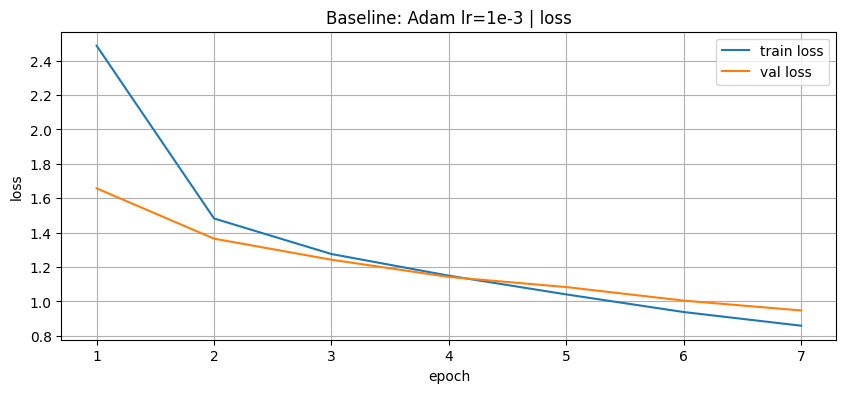

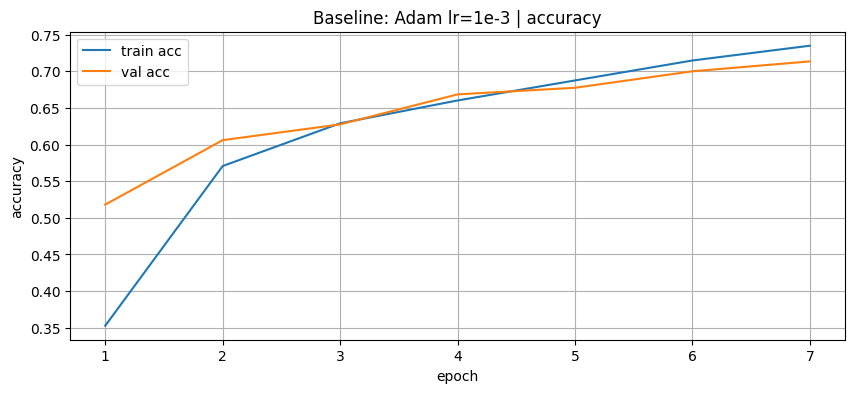

In [138]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 7  # чисто для демонстрации этого достаточно

def make_model():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

baseline_model = make_model()
baseline_opt = make_optimizer(baseline_model, kind="adam", lr=1e-3, weight_decay=0.0)

baseline_hist = fit(baseline_model, train_loader, val_loader, baseline_opt, criterion, epochs=EPOCHS)
plot_history(baseline_hist, title="Baseline: Adam lr=1e-3")


Experiment O1: Adam lr=0.1
Epoch 01/7 | train loss 19.3347, acc 0.018 | val loss 3.8723, acc 0.019 | 3.5s
Epoch 02/7 | train loss 3.8671, acc 0.020 | val loss 3.8588, acc 0.019 | 2.7s
Epoch 03/7 | train loss 3.8637, acc 0.022 | val loss 3.8649, acc 0.028 | 2.8s
Epoch 04/7 | train loss 3.8633, acc 0.020 | val loss 3.8594, acc 0.019 | 2.8s
Epoch 05/7 | train loss 3.8634, acc 0.022 | val loss 3.8601, acc 0.019 | 3.5s
Epoch 06/7 | train loss 3.8659, acc 0.019 | val loss 3.8650, acc 0.019 | 2.7s
Epoch 07/7 | train loss 3.8633, acc 0.022 | val loss 3.8642, acc 0.019 | 2.8s


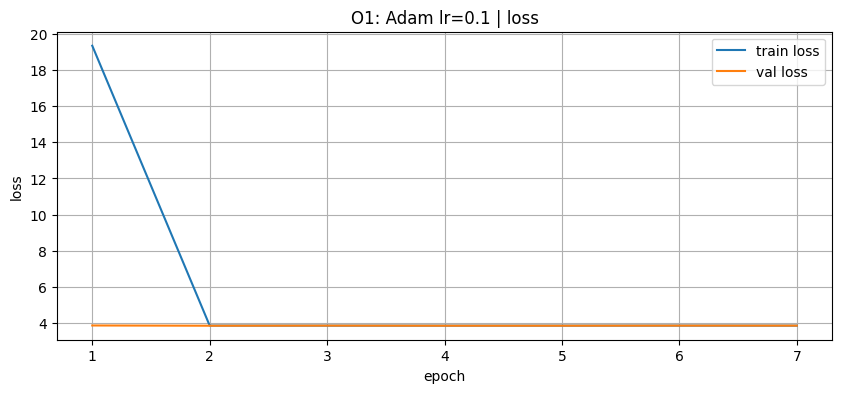

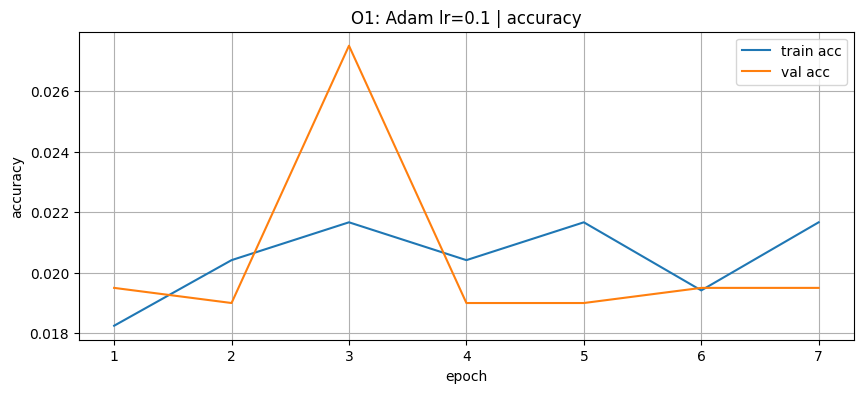


Experiment O2: Adam lr=1e-05
Epoch 01/7 | train loss 3.8405, acc 0.032 | val loss 3.8316, acc 0.038 | 2.7s
Epoch 02/7 | train loss 3.8079, acc 0.056 | val loss 3.7963, acc 0.067 | 3.4s
Epoch 03/7 | train loss 3.7666, acc 0.098 | val loss 3.7533, acc 0.103 | 2.8s
Epoch 04/7 | train loss 3.7174, acc 0.135 | val loss 3.7022, acc 0.130 | 2.7s
Epoch 05/7 | train loss 3.6592, acc 0.162 | val loss 3.6410, acc 0.155 | 2.7s
Epoch 06/7 | train loss 3.5927, acc 0.184 | val loss 3.5727, acc 0.172 | 3.0s
Epoch 07/7 | train loss 3.5193, acc 0.208 | val loss 3.4967, acc 0.191 | 3.2s


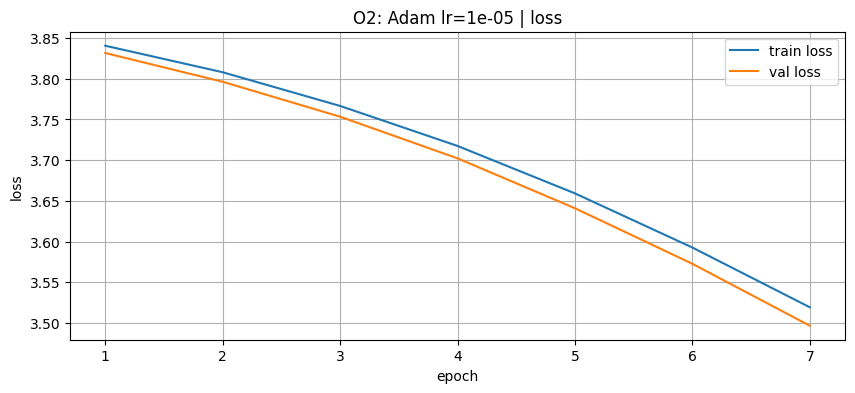

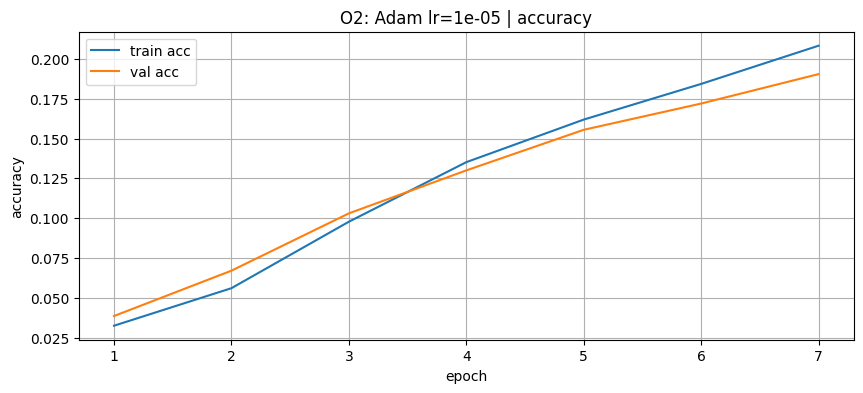

In [139]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("O1", 1e-1),
    ("O2",  1e-5)
]

results_lr = []
for name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr)
    results_lr.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")


O3: SGD lr=0.01 momentum=0.9 weight_decay=1e-4
Epoch 01/10 | train loss 3.5375, acc 0.127 | val loss 2.7911, acc 0.330 | 4.0s
Epoch 02/10 | train loss 2.0593, acc 0.446 | val loss 1.7191, acc 0.508 | 2.7s
Epoch 03/10 | train loss 1.5219, acc 0.561 | val loss 1.4234, acc 0.601 | 2.7s
Epoch 04/10 | train loss 1.3455, acc 0.611 | val loss 1.3060, acc 0.625 | 2.7s
Epoch 05/10 | train loss 1.2240, acc 0.644 | val loss 1.2560, acc 0.634 | 3.4s
Epoch 06/10 | train loss 1.1381, acc 0.663 | val loss 1.1467, acc 0.673 | 2.7s
Epoch 07/10 | train loss 1.0434, acc 0.687 | val loss 1.0926, acc 0.679 | 2.7s
Epoch 08/10 | train loss 0.9707, acc 0.712 | val loss 1.0364, acc 0.693 | 2.7s
Epoch 09/10 | train loss 0.8960, acc 0.730 | val loss 0.9922, acc 0.706 | 3.1s
Epoch 10/10 | train loss 0.8357, acc 0.743 | val loss 0.9513, acc 0.718 | 2.9s


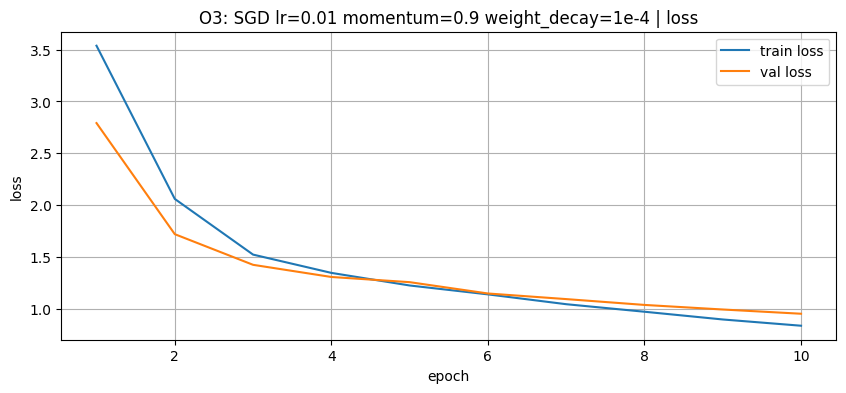

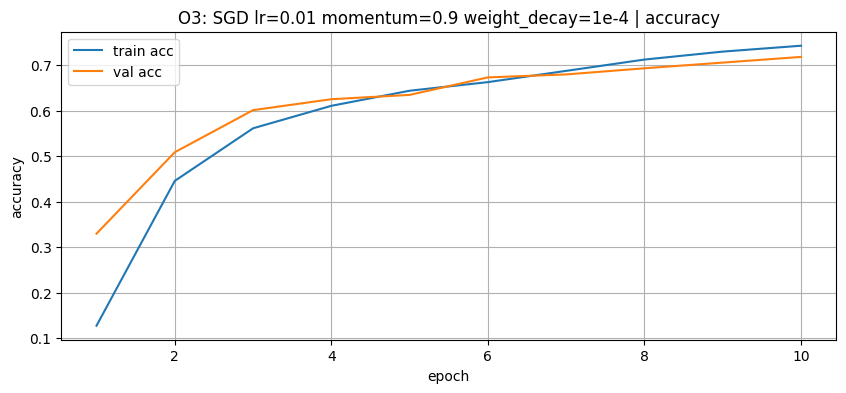

In [141]:
results_opt = []

print("\n" + "="*80)
print("O3: SGD lr=0.01 momentum=0.9 weight_decay=1e-4")
res_sgd = run_experiment(exp_id="OPT_SGD", optimizer_kind="sgd", lr=0.01, momentum=0.9, weight_decay=1e-4, epochs = 10)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="O3: SGD lr=0.01 momentum=0.9 weight_decay=1e-4")

rows = []
for r in results_opt:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })
